In [1]:
import torch
import cv2
import os
import matplotlib 
from matplotlib import pyplot as plt 
import imghdr
import numpy as np 
import torch.nn as nn
from PIL import Image
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch.optim as optim
torch.backends.cudnn.benchmark = True

In [2]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    
    transforms.ColorJitter(
        brightness=0.6,
        contrast=0.6,
        saturation=0.6,
        hue=0.1
    ),
    
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = mean,
        std = std
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),          # Resize
    transforms.CenterCrop(224),             
    transforms.ToTensor(),
    transforms.Normalize(mean=mean,
                         std=std)
])

In [3]:
train_dataset = ImageFolder(
    root = 'tomato_data/train',
    transform = train_transforms
)

val_dataset = ImageFolder(
    root = 'tomato_data/val',
    transform = val_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle = True, 
    num_workers = 4
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 64,
    shuffle = False, 
    num_workers = 4
)

In [4]:
print(train_dataset.classes)
print(f"Training images: {len(train_dataset)}")
print(val_dataset.classes)
print(f"Validation images: {len(val_dataset)}")
from collections import Counter
labels = [label for _, label in train_dataset.samples]
print(Counter(labels))

['Damaged', 'Old', 'Ripe', 'Unripe']
Training images: 6530
['Damaged', 'Old', 'Ripe', 'Unripe']
Validation images: 724
Counter({1: 1997, 2: 1994, 3: 1584, 0: 955})


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print(torch.cuda.get_device_name(0))

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4) 

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

cuda
NVIDIA GeForce RTX 4050 Laptop GPU


In [6]:
scaler = torch.cuda.amp.GradScaler()

num_epochs = 5

for epoch in range(num_epochs):


    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= train_total
    train_acc = train_correct / train_total



    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total


    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")



Epoch [1/5]
Train Loss: 0.7944 | Train Acc: 0.7821
Val   Loss: 0.5263 | Val   Acc: 0.9420

Epoch [2/5]
Train Loss: 0.5695 | Train Acc: 0.8908
Val   Loss: 0.5107 | Val   Acc: 0.9199

Epoch [3/5]
Train Loss: 0.5341 | Train Acc: 0.9093
Val   Loss: 0.4402 | Val   Acc: 0.9572

Epoch [4/5]
Train Loss: 0.5138 | Train Acc: 0.9139
Val   Loss: 0.4356 | Val   Acc: 0.9641

Epoch [5/5]
Train Loss: 0.5028 | Train Acc: 0.9250
Val   Loss: 0.4257 | Val   Acc: 0.9724


In [7]:
torch.save(model.state_dict(), "best_resnet50_tomato.pth")
print("model saved")

model saved


In [6]:
model = models.resnet50(weights=None)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)

model.load_state_dict(torch.load("best_resnet50_tomato.pth"))
model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
class_names = train_dataset.classes

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = val_transforms(image)
    image = image.unsqueeze(0)
    image = image.to(device)

    with torch.no_grad():
        with torch.cuda.amp.autocast():
            outputs = model(image) 
            _, predicted = torch.max(outputs, 1)

    predicted_class = class_names[predicted.item()]
    return predicted_class

In [8]:
features = None
gradients = None

def forward_hook(module, input, output):
    global features
    features = output

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

target_layer = model.layer4[-1]

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

In [9]:
def grad_cam_image(image_path):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = val_transforms(image).unsqueeze(0).to(device)

    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, pred_class].backward()

    grads = gradients[0].detach().cpu().numpy()
    fmap  = features[0].detach().cpu().numpy()

    weights = np.mean(grads, axis=(1, 2))

    cam = np.zeros(fmap.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * fmap[i]

    cam = np.maximum(cam, 0)
    cam = cam / cam.max()

    cam = cv2.resize(cam, (224, 224))

    image_np = np.array(image.resize((224, 224)))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = heatmap / 255.0

    overlay = heatmap + image_np / 255.0
    overlay = overlay / overlay.max()

    return image_np, overlay, pred_class

In [10]:
def predict_folder(folder_path):
    model.eval()

    class_names = train_dataset.classes
    results = {}

    for filename in os.listdir(folder_path):

        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(folder_path, filename)

            image = Image.open(image_path).convert("RGB")
            image_tensor = val_transforms(image).unsqueeze(0).to(device)


            with torch.no_grad():
                outputs = model(image_tensor)
                probs = torch.softmax(outputs, dim=1)
                confidence, predicted = torch.max(probs, 1)

            predicted_class = class_names[predicted.item()]
            confidence = confidence.item()

            print(f"{filename} → {predicted_class} ({confidence:.4f})")

            original, cam_overlay, _ = grad_cam_image(image_path)

            plt.figure(figsize=(8, 4))

            plt.subplot(1, 2, 1)
            plt.imshow(original)
            plt.title("Original")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.imshow(cam_overlay)
            plt.title(f"Grad-CAM: {predicted_class}")
            plt.axis("off")

            plt.show()

            results[filename] = (predicted_class, confidence)

    return results

googe_unseen.png → Unripe (0.8656)


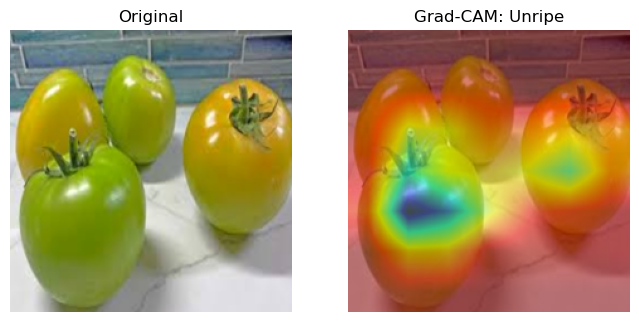

unseen1.jpg → Damaged (0.5082)


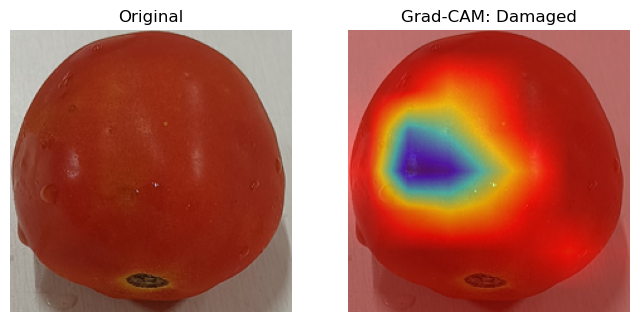

unseen2.jpg → Damaged (0.7678)


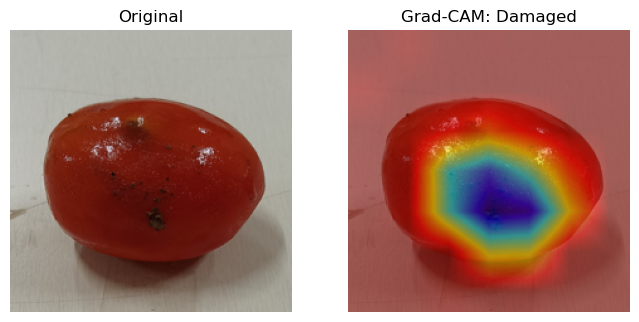

unseen3.jpg → Old (0.5732)


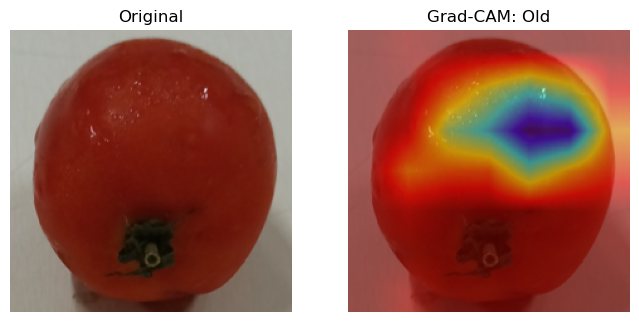

unseen4.jpg → Old (0.7929)


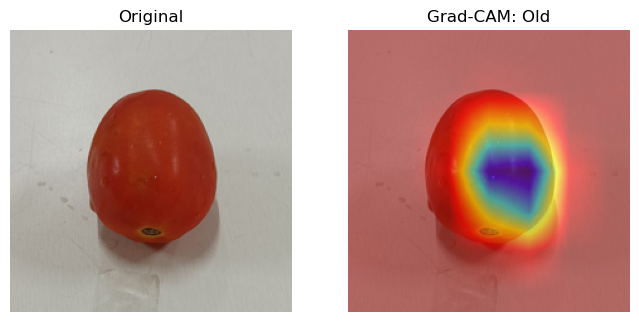

{'googe_unseen.png': ('Unripe', 0.8655794262886047),
 'unseen1.jpg': ('Damaged', 0.5082131028175354),
 'unseen2.jpg': ('Damaged', 0.7677886486053467),
 'unseen3.jpg': ('Old', 0.5731683969497681),
 'unseen4.jpg': ('Old', 0.7929221987724304)}

In [12]:
predict_folder('unseen_images')